<a href="https://colab.research.google.com/github/zahrasyifaa/Text-Classification/blob/main/modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import pickle
import scipy.sparse as sp
import ast
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# **SPLIT DATA**

In [ ]:
# LOAD DATA
df = pd.read_excel('data_stemming.xlsx')

if isinstance(df['tokens_stem'].iloc[0], str):
    df['tokens_stem'] = df['tokens_stem'].apply(ast.literal_eval)

# Gabung tokens menjadi string
df['teks_gabung'] = df['tokens_stem'].apply(lambda x: ' '.join(x))

X = df['teks_gabung']
y = df['label']

print(f"Total data     : {len(df)} baris")
print(f"Distribusi label:\n{y.value_counts().to_string()}\n")

# SPLIT DATA 4 RASIO
splits = [
    ('90:10', 0.10),
    ('80:20', 0.20),
    ('70:30', 0.30),
    ('60:40', 0.40),
]

print(f"{'Rasio':<10} {'Train':>8} {'Test':>8} {'Train L0':>10} {'Train L1':>10} {'Test L0':>10} {'Test L1':>10}")
print('-' * 70)

for nama, test_size in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Simpan
    rasio = nama.replace(':', '')
    X_train.to_csv(f'X_train_{rasio}.csv', index=False)
    X_test.to_csv(f'X_test_{rasio}.csv',   index=False)
    y_train.to_csv(f'y_train_{rasio}.csv', index=False)
    y_test.to_csv(f'y_test_{rasio}.csv',   index=False)

    print(f"{nama:<10} {len(X_train):>8} {len(X_test):>8} "
          f"{(y_train==0).sum():>10} {(y_train==1).sum():>10} "
          f"{(y_test==0).sum():>10} {(y_test==1).sum():>10}")

print(f"\nFile tersimpan:")
for nama, _ in splits:
    rasio = nama.replace(':', '')
    print(f"  X_train_{rasio}.csv, X_test_{rasio}.csv")
    print(f"  y_train_{rasio}.csv, y_test_{rasio}.csv")

Total data     : 17703 baris
Distribusi label:
label
0    8865
1    8838

Rasio         Train     Test   Train L0   Train L1    Test L0    Test L1
----------------------------------------------------------------------
90:10         15932     1771       7978       7954        887        884
80:20         14162     3541       7092       7070       1773       1768
70:30         12392     5311       6205       6187       2660       2651
60:40         10621     7082       5319       5302       3546       3536

File tersimpan:
  X_train_9010.csv, X_test_9010.csv
  y_train_9010.csv, y_test_9010.csv
  X_train_8020.csv, X_test_8020.csv
  y_train_8020.csv, y_test_8020.csv
  X_train_7030.csv, X_test_7030.csv
  y_train_7030.csv, y_test_7030.csv
  X_train_6040.csv, X_test_6040.csv
  y_train_6040.csv, y_test_6040.csv


# **TF-IDF**

In [ ]:
# TF-IDF UNTUK SETIAP RASIO SPLIT
splits = [
    ('90:10', '9010'),
    ('80:20', '8020'),
    ('70:30', '7030'),
    ('60:40', '6040'),
]

print(f"{'Rasio':<10} {'Train':>8} {'Test':>8} {'Fitur':>8}")
print('-' * 38)

for nama, rasio in splits:
    X_train = pd.read_csv(f'X_train_{rasio}.csv').squeeze()
    X_test  = pd.read_csv(f'X_test_{rasio}.csv').squeeze()

    vectorizer = TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )

    # Fit HANYA pada training
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf  = vectorizer.transform(X_test)

    # Simpan
    sp.save_npz(f'X_train_{rasio}_tfidf.npz', X_train_tfidf)
    sp.save_npz(f'X_test_{rasio}_tfidf.npz',  X_test_tfidf)
    with open(f'tfidf_vectorizer_{rasio}.pkl', 'wb') as f:
        pickle.dump(vectorizer, f)

    print(f"{nama:<10} {X_train_tfidf.shape[0]:>8} {X_test_tfidf.shape[0]:>8} {X_train_tfidf.shape[1]:>8}")

print(f"\nFile tersimpan per rasio:")
for _, rasio in splits:
    print(f"  X_train_{rasio}_tfidf.npz, X_test_{rasio}_tfidf.npz")
    print(f"  tfidf_vectorizer_{rasio}.pkl")

Rasio         Train     Test    Fitur
--------------------------------------
90:10         15932     1771    15000
80:20         14162     3541    15000
70:30         12392     5311    15000
60:40         10621     7082    15000

File tersimpan per rasio:
  X_train_9010_tfidf.npz, X_test_9010_tfidf.npz
  tfidf_vectorizer_9010.pkl
  X_train_8020_tfidf.npz, X_test_8020_tfidf.npz
  tfidf_vectorizer_8020.pkl
  X_train_7030_tfidf.npz, X_test_7030_tfidf.npz
  tfidf_vectorizer_7030.pkl
  X_train_6040_tfidf.npz, X_test_6040_tfidf.npz
  tfidf_vectorizer_6040.pkl


# **SVM**


############################################################
  HASIL SVM — RASIO 90:10
############################################################

  Data training  : 15,932 baris
  Data testing   : 1,771 baris
  Jumlah fitur   : 15,000

  Distribusi label training:
    Kehamilan (0) : 7,978
    Menstruasi (1): 7,954

  Distribusi label testing:
    Kehamilan (0) : 887
    Menstruasi (1): 884

  Classification Report:

  Kelas                 Precision   Recall       F1  Support
  ------------------------------------------------------
  Kehamilan (0)            0.9269   0.9290   0.9279      887
  Menstruasi (1)           0.9286   0.9265   0.9275      884
  ------------------------------------------------------
  Akurasi                                    0.9277     1771
  Macro avg                0.9277   0.9277   0.9277     1771
  Weighted avg             0.9277   0.9277   0.9277     1771


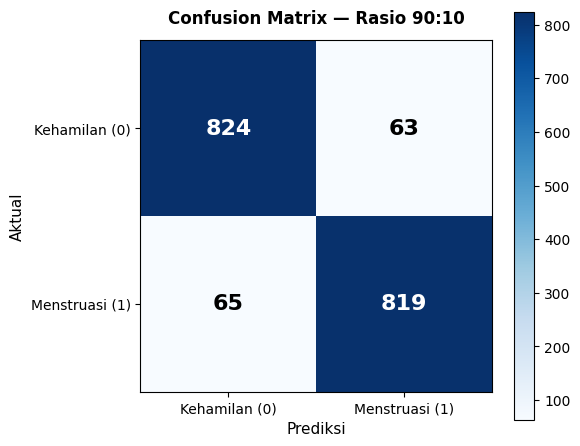


############################################################
  HASIL SVM — RASIO 80:20
############################################################

  Data training  : 14,162 baris
  Data testing   : 3,541 baris
  Jumlah fitur   : 15,000

  Distribusi label training:
    Kehamilan (0) : 7,092
    Menstruasi (1): 7,070

  Distribusi label testing:
    Kehamilan (0) : 1,773
    Menstruasi (1): 1,768

  Classification Report:

  Kelas                 Precision   Recall       F1  Support
  ------------------------------------------------------
  Kehamilan (0)            0.9396   0.9205   0.9299     1773
  Menstruasi (1)           0.9218   0.9406   0.9311     1768
  ------------------------------------------------------
  Akurasi                                    0.9305     3541
  Macro avg                0.9307   0.9305   0.9305     3541
  Weighted avg             0.9307   0.9305   0.9305     3541


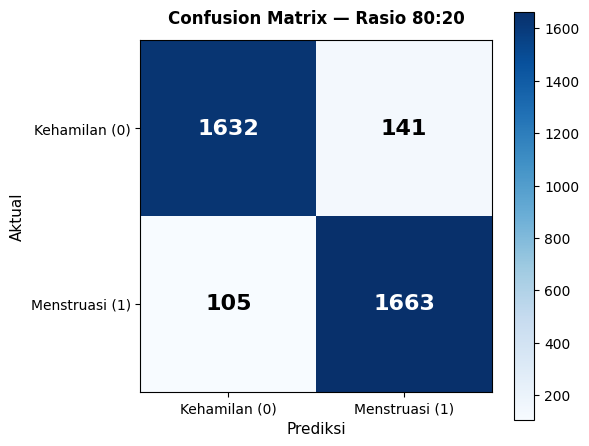


############################################################
  HASIL SVM — RASIO 70:30
############################################################

  Data training  : 12,392 baris
  Data testing   : 5,311 baris
  Jumlah fitur   : 15,000

  Distribusi label training:
    Kehamilan (0) : 6,205
    Menstruasi (1): 6,187

  Distribusi label testing:
    Kehamilan (0) : 2,660
    Menstruasi (1): 2,651

  Classification Report:

  Kelas                 Precision   Recall       F1  Support
  ------------------------------------------------------
  Kehamilan (0)            0.9354   0.9248   0.9301     2660
  Menstruasi (1)           0.9254   0.9359   0.9306     2651
  ------------------------------------------------------
  Akurasi                                    0.9303     5311
  Macro avg                0.9304   0.9303   0.9303     5311
  Weighted avg             0.9304   0.9303   0.9303     5311


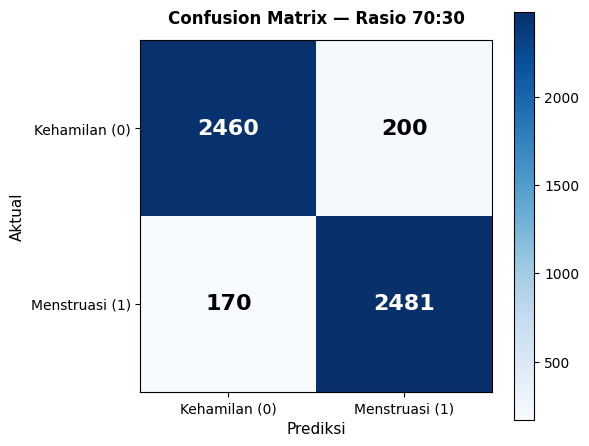


############################################################
  HASIL SVM — RASIO 60:40
############################################################

  Data training  : 10,621 baris
  Data testing   : 7,082 baris
  Jumlah fitur   : 15,000

  Distribusi label training:
    Kehamilan (0) : 5,319
    Menstruasi (1): 5,302

  Distribusi label testing:
    Kehamilan (0) : 3,546
    Menstruasi (1): 3,536

  Classification Report:

  Kelas                 Precision   Recall       F1  Support
  ------------------------------------------------------
  Kehamilan (0)            0.9313   0.9250   0.9281     3546
  Menstruasi (1)           0.9253   0.9316   0.9284     3536
  ------------------------------------------------------
  Akurasi                                    0.9283     7082
  Macro avg                0.9283   0.9283   0.9283     7082
  Weighted avg             0.9283   0.9283   0.9283     7082


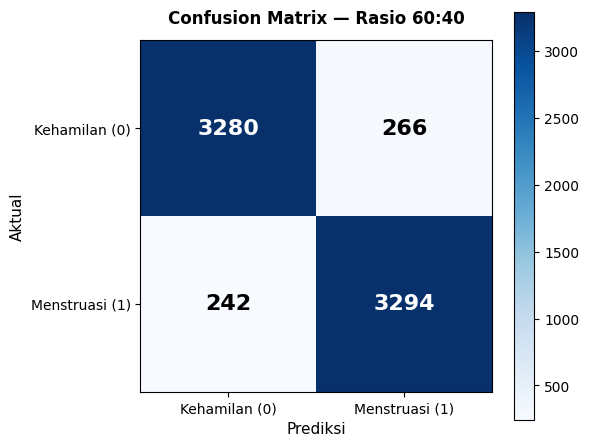


############################################################
  PERBANDINGAN SEMUA RASIO SPLIT
############################################################

  Rasio           Akurasi   Precision   Recall       F1
  -----------------------------------------------------
  90:10            0.9277      0.9277   0.9277   0.9277
  80:20 ★          0.9305      0.9307   0.9305   0.9305
  70:30            0.9303      0.9304   0.9303   0.9303
  60:40            0.9283      0.9283   0.9283   0.9283

  ★ = Rasio terbaik


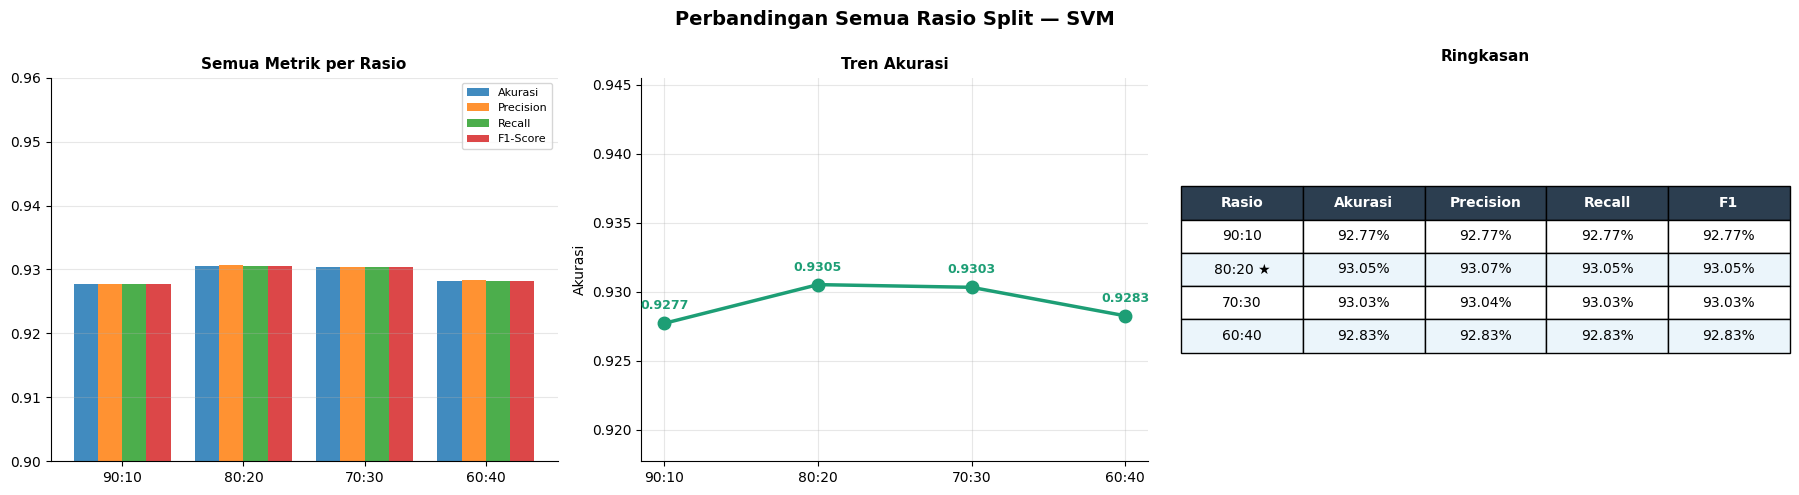


  Semua model tersimpan:
    model_svm_9010.pkl
    model_svm_8020.pkl
    model_svm_7030.pkl
    model_svm_6040.pkl


In [ ]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import pickle
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score
)

# %matplotlib inline  ← aktifkan jika di Jupyter/Colab

# LOAD DATA SPLIT + TF-IDF
rasio_splits = [
    ('90:10', '9010'),
    ('80:20', '8020'),
    ('70:30', '7030'),
    ('60:40', '6040'),
]

tfidf_splits = {}
for nama, rasio in rasio_splits:
    X_train = sp.load_npz(f'X_train_{rasio}_tfidf.npz')
    X_test  = sp.load_npz(f'X_test_{rasio}_tfidf.npz')
    y_train = pd.read_csv(f'y_train_{rasio}.csv').squeeze()
    y_test  = pd.read_csv(f'y_test_{rasio}.csv').squeeze()
    tfidf_splits[nama] = (X_train, X_test, y_train, y_test)

# TRAINING SVM DAN OUTPUT PER RASIO
hasil = {}

for nama, rasio in rasio_splits:

    X_train, X_test, y_train, y_test = tfidf_splits[nama]

    # Training
    model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Simpan hasil
    hasil[nama] = {
        'model'    : model,
        'y_train'  : y_train,
        'y_test'   : y_test,
        'y_pred'   : y_pred,
        'acc'      : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall'   : recall_score(y_test, y_pred, average='weighted'),
        'f1'       : f1_score(y_test, y_pred, average='weighted'),
        'cm'       : confusion_matrix(y_test, y_pred),
        'report'   : classification_report(
                        y_test, y_pred,
                        target_names=['Kehamilan (0)', 'Menstruasi (1)'],
                        output_dict=True
                     ),
        'n_train'  : X_train.shape[0],
        'n_test'   : X_test.shape[0],
        'n_fitur'  : X_train.shape[1],
    }

    # Simpan model
    with open(f'model_svm_{rasio}.pkl', 'wb') as f:
        pickle.dump(model, f)

    # OUTPUT PER RASIO
    h   = hasil[nama]
    rep = h['report']

    print(f"\n{'#'*60}")
    print(f"  HASIL SVM — RASIO {nama}")
    print(f"{'#'*60}")

    # Info data
    print(f"\n  Data training  : {h['n_train']:,} baris")
    print(f"  Data testing   : {h['n_test']:,} baris")
    print(f"  Jumlah fitur   : {h['n_fitur']:,}")
    print(f"\n  Distribusi label training:")
    print(f"    Kehamilan (0) : {(y_train==0).sum():,}")
    print(f"    Menstruasi (1): {(y_train==1).sum():,}")
    print(f"\n  Distribusi label testing:")
    print(f"    Kehamilan (0) : {(y_test==0).sum():,}")
    print(f"    Menstruasi (1): {(y_test==1).sum():,}")

    # Classification report
    print(f"\n  Classification Report:")
    labels_rep = ['Kehamilan (0)', 'Menstruasi (1)']
    print(f"\n  {'Kelas':<20} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>8}")
    print(f"  {'-'*54}")
    for kelas in labels_rep:
        r = rep[kelas]
        print(f"  {kelas:<20} {r['precision']:>10.4f} {r['recall']:>8.4f} {r['f1-score']:>8.4f} {int(r['support']):>8}")
    print(f"  {'-'*54}")
    total_support = int(rep['weighted avg']['support'])
    print(f"  {'Akurasi':<20} {'':>10} {'':>8} {h['acc']:>8.4f} {total_support:>8}")
    ma = rep['macro avg']
    print(f"  {'Macro avg':<20} {ma['precision']:>10.4f} {ma['recall']:>8.4f} {ma['f1-score']:>8.4f} {int(ma['support']):>8}")
    wa = rep['weighted avg']
    print(f"  {'Weighted avg':<20} {wa['precision']:>10.4f} {wa['recall']:>8.4f} {wa['f1-score']:>8.4f} {int(wa['support']):>8}")

    # Confusion matrix visual
    cm      = h['cm']
    fig, ax = plt.subplots(figsize=(6, 5))
    im      = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    thresh  = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i,j], 'd'),
                    ha='center', va='center', fontsize=16, fontweight='bold',
                    color='white' if cm[i,j] > thresh else 'black')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Kehamilan (0)', 'Menstruasi (1)'], fontsize=10)
    ax.set_yticks([0,1]); ax.set_yticklabels(['Kehamilan (0)', 'Menstruasi (1)'], fontsize=10)
    ax.set_xlabel('Prediksi', fontsize=11)
    ax.set_ylabel('Aktual', fontsize=11)
    ax.set_title(f'Confusion Matrix — Rasio {nama}', fontsize=12, fontweight='bold', pad=12)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# PERBANDINGAN SEMUA RASIO
print(f"\n{'#'*60}")
print(f"  PERBANDINGAN SEMUA RASIO SPLIT")
print(f"{'#'*60}")

tanda_terbaik = max(hasil, key=lambda x: hasil[x]['acc'])

print(f"\n  {'Rasio':<12} {'Akurasi':>10} {'Precision':>11} {'Recall':>8} {'F1':>8}")
print(f"  {'-'*53}")
for nama, _ in rasio_splits:
    h     = hasil[nama]
    tanda = ' ★' if nama == tanda_terbaik else ''
    print(f"  {nama+tanda:<12} {h['acc']:>10.4f} {h['precision']:>11.4f} {h['recall']:>8.4f} {h['f1']:>8.4f}")
print(f"\n  ★ = Rasio terbaik")

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Perbandingan Semua Rasio Split — SVM', fontsize=14, fontweight='bold')

rasio_labels = [s[0] for s in rasio_splits]
colors       = ['#1D9E75', '#378ADD', '#D85A30', '#9B59B6']

# Bar chart semua metrik
metrik_list = [
    ('acc',       'Akurasi'),
    ('precision', 'Precision'),
    ('recall',    'Recall'),
    ('f1',        'F1-Score'),
]
ax = axes[0]
x  = np.arange(len(rasio_splits))
w  = 0.2
for i, (key, label) in enumerate(metrik_list):
    vals = [hasil[n][key] for n, _ in rasio_splits]
    ax.bar(x + i*w - 1.5*w, vals, w, label=label, alpha=0.85)
ax.set_title('Semua Metrik per Rasio', fontsize=11, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(rasio_labels)
ax.set_ylim(0.90, 0.96)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Line chart tren akurasi
ax2  = axes[1]
accs = [hasil[n]['acc'] for n, _ in rasio_splits]
ax2.plot(rasio_labels, accs, marker='o', linewidth=2.5, color='#1D9E75', markersize=9)
for i, v in enumerate(accs):
    ax2.annotate(f'{v:.4f}', (rasio_labels[i], v),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, fontweight='bold', color='#1D9E75')
ax2.set_title('Tren Akurasi', fontsize=11, fontweight='bold')
ax2.set_ylabel('Akurasi', fontsize=10)
ax2.set_ylim(min(accs)-0.01, max(accs)+0.015)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.3)

# Tabel ringkasan
ax3 = axes[2]
ax3.axis('off')
data_tbl = []
for nama, _ in rasio_splits:
    h     = hasil[nama]
    tanda = ' ★' if nama == tanda_terbaik else ''
    data_tbl.append([
        nama + tanda,
        f"{h['acc']*100:.2f}%",
        f"{h['precision']*100:.2f}%",
        f"{h['recall']*100:.2f}%",
        f"{h['f1']*100:.2f}%",
    ])
tbl = ax3.table(
    cellText=data_tbl,
    colLabels=['Rasio', 'Akurasi', 'Precision', 'Recall', 'F1'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.0)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EBF5FB')
ax3.set_title('Ringkasan', fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"  Semua model tersimpan:")
for _, rasio in rasio_splits:
    print(f"    model_svm_{rasio}.pkl")
print(f"{'='*60}")

# **Logistic Regression**


############################################################
  HASIL LOGISTIC REGRESSION — RASIO 90:10
############################################################

  Data training  : 15,932 baris
  Data testing   : 1,771 baris
  Jumlah fitur   : 15,000

  Distribusi label training:
    Kehamilan (0) : 7,978
    Menstruasi (1): 7,954

  Distribusi label testing:
    Kehamilan (0) : 887
    Menstruasi (1): 884

  Classification Report:

  Kelas                 Precision   Recall       F1  Support
  ------------------------------------------------------
  Kehamilan (0)            0.9275   0.9369   0.9321      887
  Menstruasi (1)           0.9360   0.9265   0.9312      884
  ------------------------------------------------------
  Akurasi                                    0.9317     1771
  Macro avg                0.9317   0.9317   0.9317     1771
  Weighted avg             0.9317   0.9317   0.9317     1771


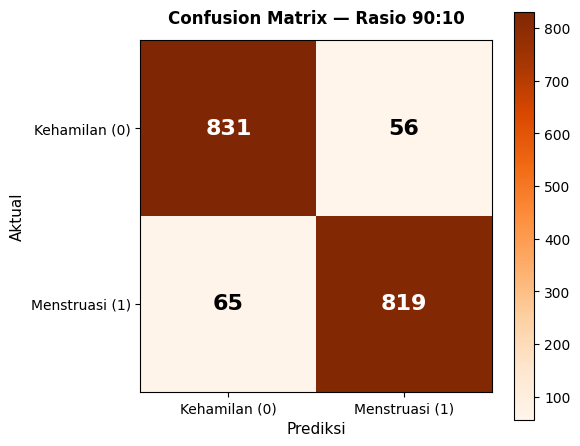


############################################################
  HASIL LOGISTIC REGRESSION — RASIO 80:20
############################################################

  Data training  : 14,162 baris
  Data testing   : 3,541 baris
  Jumlah fitur   : 15,000

  Distribusi label training:
    Kehamilan (0) : 7,092
    Menstruasi (1): 7,070

  Distribusi label testing:
    Kehamilan (0) : 1,773
    Menstruasi (1): 1,768

  Classification Report:

  Kelas                 Precision   Recall       F1  Support
  ------------------------------------------------------
  Kehamilan (0)            0.9382   0.9334   0.9358     1773
  Menstruasi (1)           0.9336   0.9383   0.9360     1768
  ------------------------------------------------------
  Akurasi                                    0.9359     3541
  Macro avg                0.9359   0.9359   0.9359     3541
  Weighted avg             0.9359   0.9359   0.9359     3541


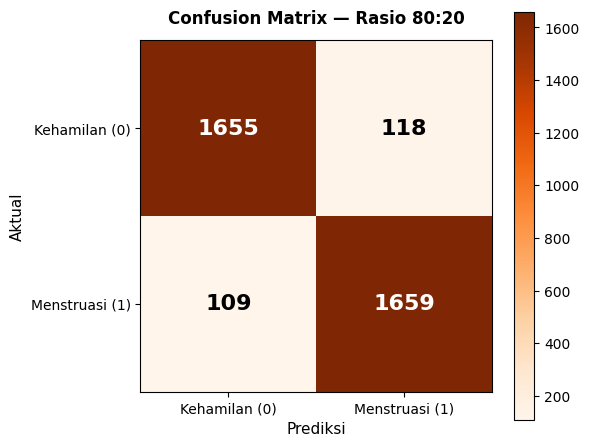


############################################################
  HASIL LOGISTIC REGRESSION — RASIO 70:30
############################################################

  Data training  : 12,392 baris
  Data testing   : 5,311 baris
  Jumlah fitur   : 15,000

  Distribusi label training:
    Kehamilan (0) : 6,205
    Menstruasi (1): 6,187

  Distribusi label testing:
    Kehamilan (0) : 2,660
    Menstruasi (1): 2,651

  Classification Report:

  Kelas                 Precision   Recall       F1  Support
  ------------------------------------------------------
  Kehamilan (0)            0.9349   0.9293   0.9321     2660
  Menstruasi (1)           0.9295   0.9351   0.9323     2651
  ------------------------------------------------------
  Akurasi                                    0.9322     5311
  Macro avg                0.9322   0.9322   0.9322     5311
  Weighted avg             0.9322   0.9322   0.9322     5311


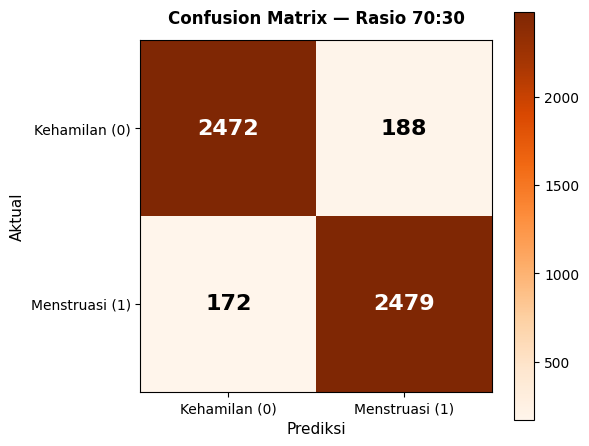


############################################################
  HASIL LOGISTIC REGRESSION — RASIO 60:40
############################################################

  Data training  : 10,621 baris
  Data testing   : 7,082 baris
  Jumlah fitur   : 15,000

  Distribusi label training:
    Kehamilan (0) : 5,319
    Menstruasi (1): 5,302

  Distribusi label testing:
    Kehamilan (0) : 3,546
    Menstruasi (1): 3,536

  Classification Report:

  Kelas                 Precision   Recall       F1  Support
  ------------------------------------------------------
  Kehamilan (0)            0.9335   0.9301   0.9318     3546
  Menstruasi (1)           0.9301   0.9335   0.9318     3536
  ------------------------------------------------------
  Akurasi                                    0.9318     7082
  Macro avg                0.9318   0.9318   0.9318     7082
  Weighted avg             0.9318   0.9318   0.9318     7082


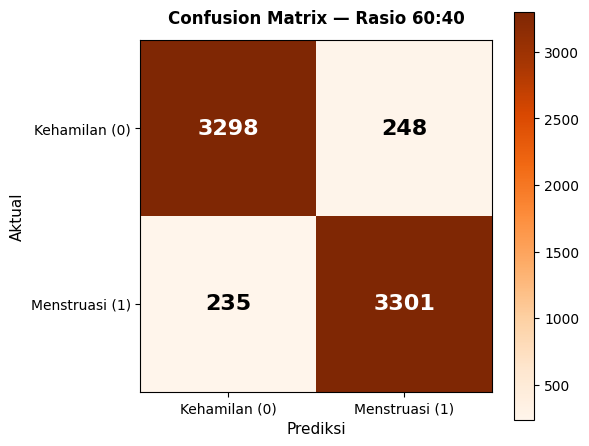


############################################################
  PERBANDINGAN SEMUA RASIO SPLIT — LOGISTIC REGRESSION
############################################################

  Rasio           Akurasi   Precision   Recall       F1
  -----------------------------------------------------
  90:10            0.9317      0.9317   0.9317   0.9317
  80:20 ★          0.9359      0.9359   0.9359   0.9359
  70:30            0.9322      0.9322   0.9322   0.9322
  60:40            0.9318      0.9318   0.9318   0.9318

  ★ = Rasio terbaik


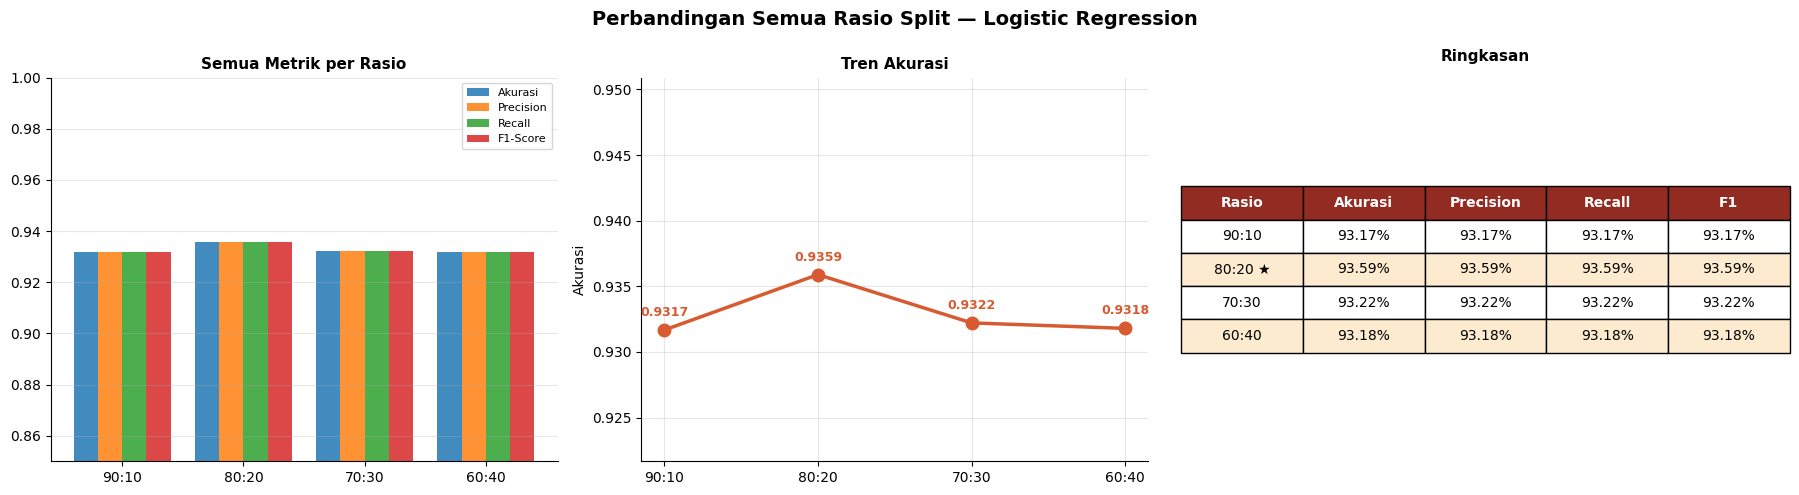


  Semua model tersimpan:
    model_lr_9010.pkl
    model_lr_8020.pkl
    model_lr_7030.pkl
    model_lr_6040.pkl


In [ ]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import pickle
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score
)

# LOAD DATA SPLIT + TF-IDF
rasio_splits = [
    ('90:10', '9010'),
    ('80:20', '8020'),
    ('70:30', '7030'),
    ('60:40', '6040'),
]

tfidf_splits = {}
for nama, rasio in rasio_splits:
    X_train = sp.load_npz(f'X_train_{rasio}_tfidf.npz')
    X_test  = sp.load_npz(f'X_test_{rasio}_tfidf.npz')
    y_train = pd.read_csv(f'y_train_{rasio}.csv').squeeze()
    y_test  = pd.read_csv(f'y_test_{rasio}.csv').squeeze()
    tfidf_splits[nama] = (X_train, X_test, y_train, y_test)

# TRAINING LOGISTIC REGRESSION DAN OUTPUT PER RASIO
hasil = {}

for nama, rasio in rasio_splits:

    X_train, X_test, y_train, y_test = tfidf_splits[nama]

    # Training
    model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Simpan hasil
    hasil[nama] = {
        'model'    : model,
        'y_train'  : y_train,
        'y_test'   : y_test,
        'y_pred'   : y_pred,
        'acc'      : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall'   : recall_score(y_test, y_pred, average='weighted'),
        'f1'       : f1_score(y_test, y_pred, average='weighted'),
        'cm'       : confusion_matrix(y_test, y_pred),
        'report'   : classification_report(
                        y_test, y_pred,
                        target_names=['Kehamilan (0)', 'Menstruasi (1)'],
                        output_dict=True
                     ),
        'n_train'  : X_train.shape[0],
        'n_test'   : X_test.shape[0],
        'n_fitur'  : X_train.shape[1],
    }

    # Simpan model
    with open(f'model_lr_{rasio}.pkl', 'wb') as f:
        pickle.dump(model, f)

    # OUTPUT PER RASIO
    h   = hasil[nama]
    rep = h['report']

    print(f"\n{'#'*60}")
    print(f"  HASIL LOGISTIC REGRESSION — RASIO {nama}")
    print(f"{'#'*60}")

    # Info data
    print(f"\n  Data training  : {h['n_train']:,} baris")
    print(f"  Data testing   : {h['n_test']:,} baris")
    print(f"  Jumlah fitur   : {h['n_fitur']:,}")
    print(f"\n  Distribusi label training:")
    print(f"    Kehamilan (0) : {(y_train==0).sum():,}")
    print(f"    Menstruasi (1): {(y_train==1).sum():,}")
    print(f"\n  Distribusi label testing:")
    print(f"    Kehamilan (0) : {(y_test==0).sum():,}")
    print(f"    Menstruasi (1): {(y_test==1).sum():,}")

    # Classification report
    print(f"\n  Classification Report:")
    labels_rep = ['Kehamilan (0)', 'Menstruasi (1)']
    print(f"\n  {'Kelas':<20} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>8}")
    print(f"  {'-'*54}")
    for kelas in labels_rep:
        r = rep[kelas]
        print(f"  {kelas:<20} {r['precision']:>10.4f} {r['recall']:>8.4f} {r['f1-score']:>8.4f} {int(r['support']):>8}")
    print(f"  {'-'*54}")
    total_support = int(rep['weighted avg']['support'])
    print(f"  {'Akurasi':<20} {'':>10} {'':>8} {h['acc']:>8.4f} {total_support:>8}")
    ma = rep['macro avg']
    print(f"  {'Macro avg':<20} {ma['precision']:>10.4f} {ma['recall']:>8.4f} {ma['f1-score']:>8.4f} {int(ma['support']):>8}")
    wa = rep['weighted avg']
    print(f"  {'Weighted avg':<20} {wa['precision']:>10.4f} {wa['recall']:>8.4f} {wa['f1-score']:>8.4f} {int(wa['support']):>8}")

    # Confusion matrix per rasio
    cm      = h['cm']
    fig, ax = plt.subplots(figsize=(6, 5))
    im      = ax.imshow(cm, interpolation='nearest', cmap='Oranges')
    thresh  = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i,j], 'd'),
                    ha='center', va='center', fontsize=16, fontweight='bold',
                    color='white' if cm[i,j] > thresh else 'black')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Kehamilan (0)', 'Menstruasi (1)'], fontsize=10)
    ax.set_yticks([0,1]); ax.set_yticklabels(['Kehamilan (0)', 'Menstruasi (1)'], fontsize=10)
    ax.set_xlabel('Prediksi', fontsize=11)
    ax.set_ylabel('Aktual', fontsize=11)
    ax.set_title(f'Confusion Matrix — Rasio {nama}', fontsize=12, fontweight='bold', pad=12)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# PERBANDINGAN SEMUA RASIO
print(f"\n{'#'*60}")
print(f"  PERBANDINGAN SEMUA RASIO SPLIT — LOGISTIC REGRESSION")
print(f"{'#'*60}")

tanda_terbaik = max(hasil, key=lambda x: hasil[x]['acc'])

print(f"\n  {'Rasio':<12} {'Akurasi':>10} {'Precision':>11} {'Recall':>8} {'F1':>8}")
print(f"  {'-'*53}")
for nama, _ in rasio_splits:
    h     = hasil[nama]
    tanda = ' ★' if nama == tanda_terbaik else ''
    print(f"  {nama+tanda:<12} {h['acc']:>10.4f} {h['precision']:>11.4f} {h['recall']:>8.4f} {h['f1']:>8.4f}")
print(f"\n  ★ = Rasio terbaik")

# VISUALISASI PERBANDINGAN
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Perbandingan Semua Rasio Split — Logistic Regression', fontsize=14, fontweight='bold')

rasio_labels = [s[0] for s in rasio_splits]

# Bar chart semua metrik
metrik_list = [
    ('acc',       'Akurasi'),
    ('precision', 'Precision'),
    ('recall',    'Recall'),
    ('f1',        'F1-Score'),
]
ax = axes[0]
x  = np.arange(len(rasio_splits))
w  = 0.2
for i, (key, label) in enumerate(metrik_list):
    vals = [hasil[n][key] for n, _ in rasio_splits]
    ax.bar(x + i*w - 1.5*w, vals, w, label=label, alpha=0.85)
ax.set_title('Semua Metrik per Rasio', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(rasio_labels)
ax.set_ylim(0.85, 1.00)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Line chart tren akurasi
ax2  = axes[1]
accs = [hasil[n]['acc'] for n, _ in rasio_splits]
ax2.plot(rasio_labels, accs, marker='o', linewidth=2.5, color='#D85A30', markersize=9)
for i, v in enumerate(accs):
    ax2.annotate(f'{v:.4f}', (rasio_labels[i], v),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, fontweight='bold', color='#D85A30')
ax2.set_title('Tren Akurasi', fontsize=11, fontweight='bold')
ax2.set_ylabel('Akurasi', fontsize=10)
ax2.set_ylim(min(accs)-0.01, max(accs)+0.015)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.3)

# Tabel ringkasan
ax3 = axes[2]
ax3.axis('off')
data_tbl = []
for nama, _ in rasio_splits:
    h     = hasil[nama]
    tanda = ' ★' if nama == tanda_terbaik else ''
    data_tbl.append([
        nama + tanda,
        f"{h['acc']*100:.2f}%",
        f"{h['precision']*100:.2f}%",
        f"{h['recall']*100:.2f}%",
        f"{h['f1']*100:.2f}%",
    ])
tbl = ax3.table(
    cellText=data_tbl,
    colLabels=['Rasio', 'Akurasi', 'Precision', 'Recall', 'F1'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.0)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#922B21')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#FDEBD0')
ax3.set_title('Ringkasan', fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"  Semua model tersimpan:")
for _, rasio in rasio_splits:
    print(f"    model_lr_{rasio}.pkl")
print(f"{'='*60}")

# **Feature Importance - Logistic Regression**

Jumlah fitur model: 15000
Vectorizer loaded, jumlah fitur: 15000

############################################################
  FEATURE IMPORTANCE — LOGISTIC REGRESSION (RASIO 80:20)
############################################################

  Top 20 kata penting — Kehamilan (0):
  Kata                    Koefisien
  ----------------------------------
  hamil                    -10.7327
  janin                     -5.5685
  usia hamil                -3.2229
  bayi                      -3.1622
  sperma                    -3.1223
  trimester                 -2.9468
  persalinan                -2.4743
  wanita hamil              -2.1019
  usia                      -2.0226
  buah                      -1.8555
  ketuban                   -1.8103
  perkembangan              -1.7864
  hamil minggu              -1.6511
  cepat hamil               -1.6122
  plasenta                  -1.5931
  hamil wanita              -1.5751
  minggu                    -1.5654
  hamil sebab               -1

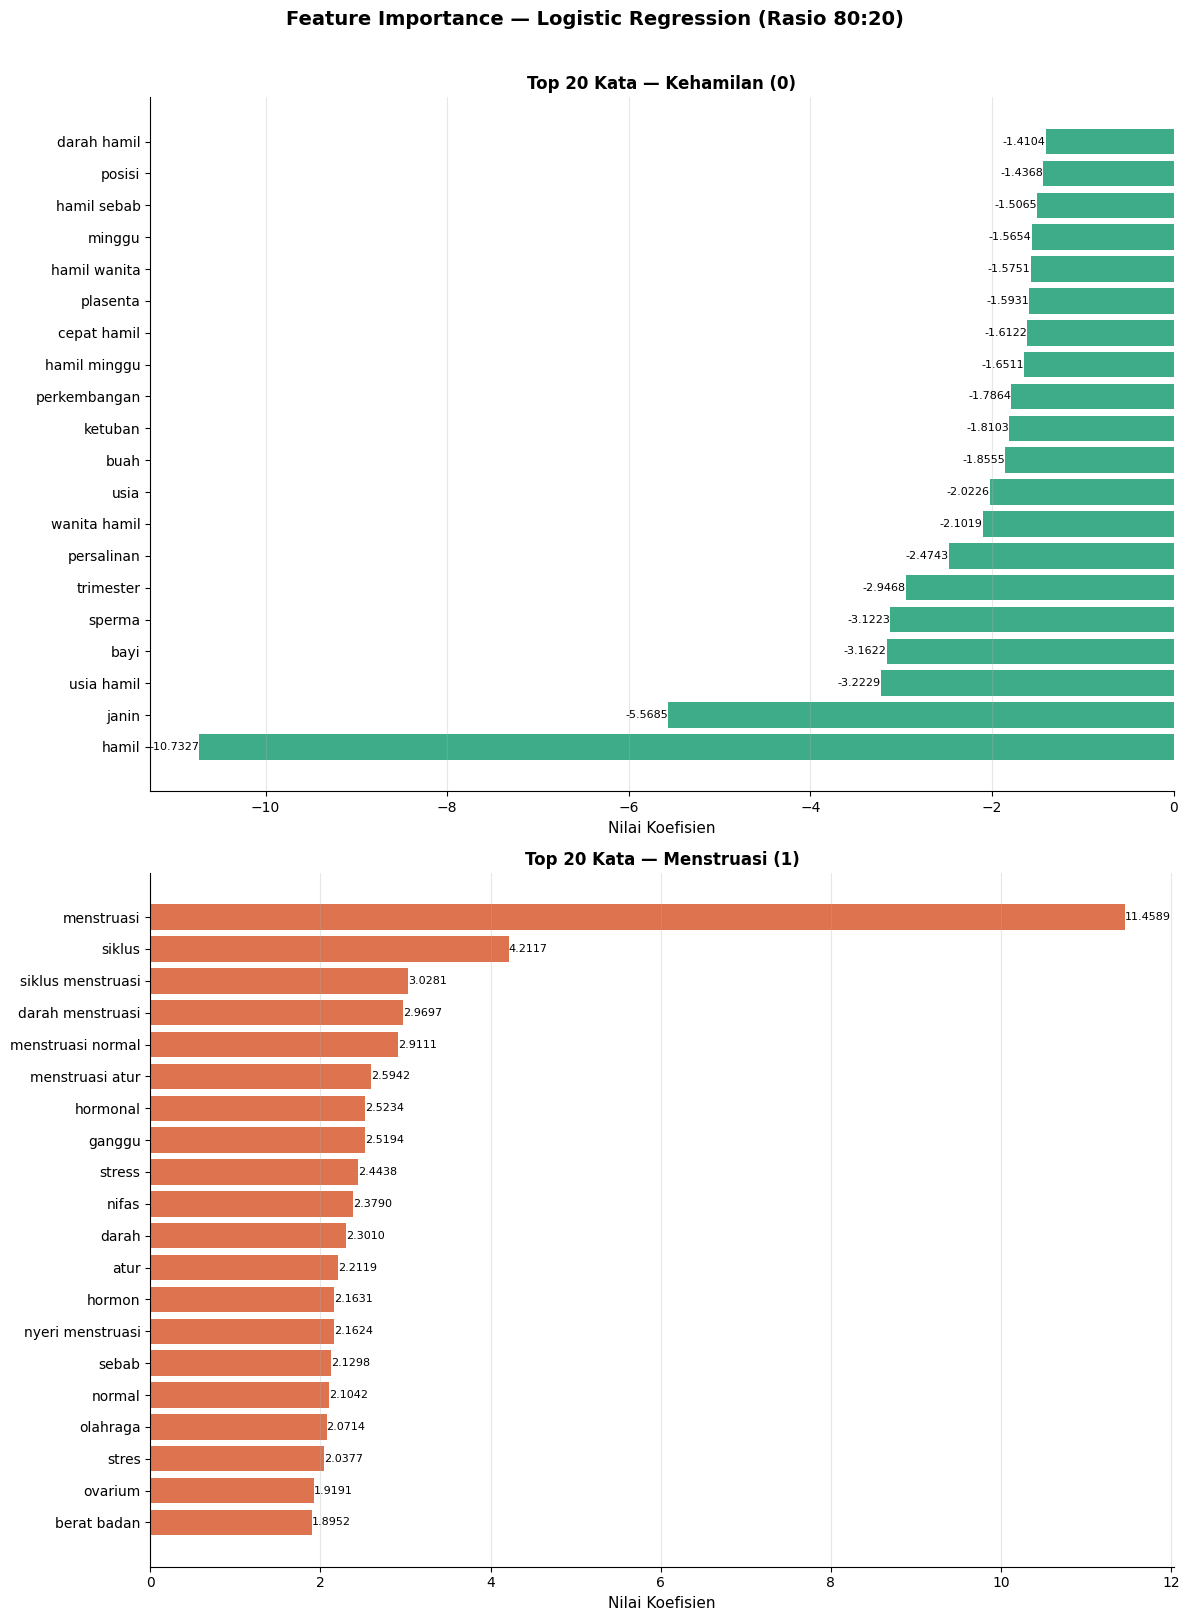

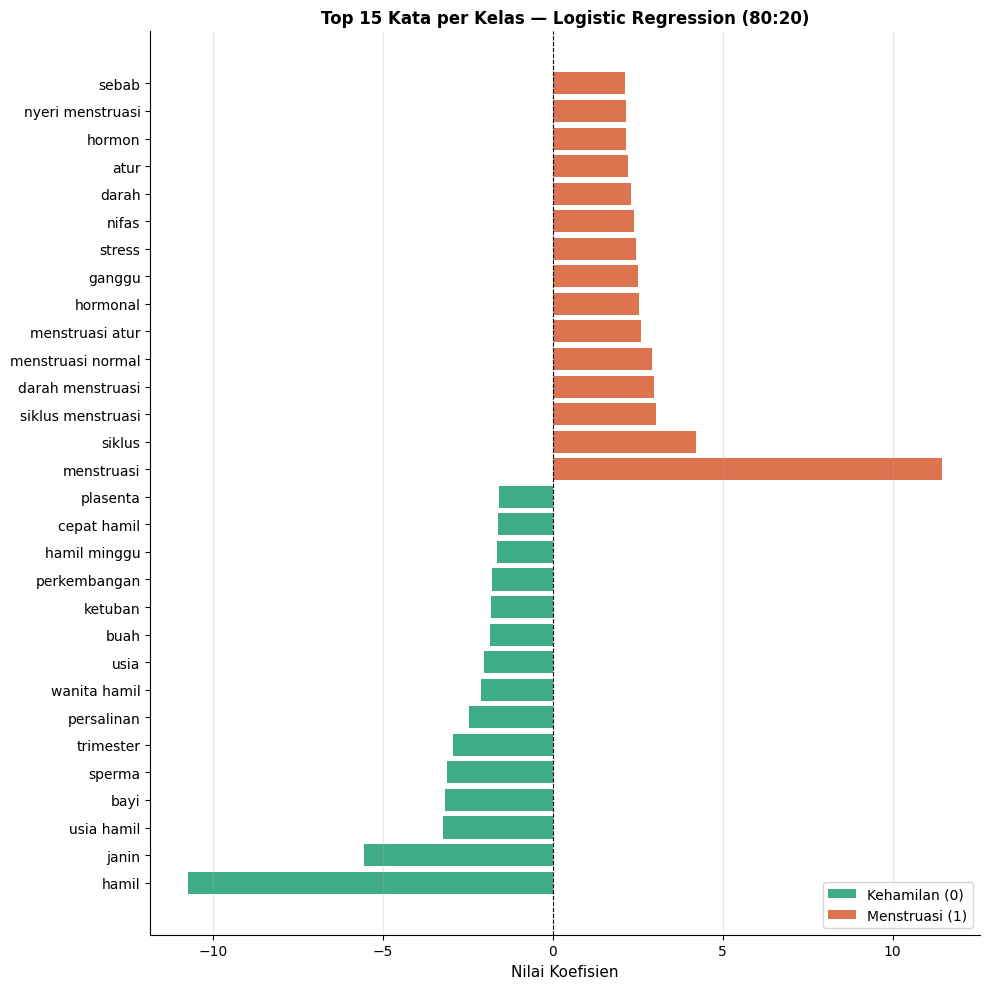

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scipy.sparse as sp
import pandas as pd
from matplotlib.patches import Patch

# LOAD MODEL 80:20
with open('model_lr_8020.pkl', 'rb') as f:
    model = pickle.load(f)

n_fitur_model = model.coef_.shape[1]
print(f"Jumlah fitur model: {n_fitur_model}")

try:
    with open('tfidf_vectorizer_8020.pkl', 'rb') as f:
        tfidf = pickle.load(f)
    feature_names = np.array(tfidf.get_feature_names_out())
    print(f"Vectorizer loaded, jumlah fitur: {len(feature_names)}")
    if len(feature_names) != n_fitur_model:
        print(f"Mismatch! Menyesuaikan feature_names ke {n_fitur_model} fitur...")
        feature_names = feature_names[:n_fitur_model]
except FileNotFoundError:
    print("Vectorizer tidak ditemukan, menggunakan nama fitur generic...")
    feature_names = np.array([f'fitur_{i}' for i in range(n_fitur_model)])

# AMBIL KOEFISIEN
koefisien = model.coef_[0]
top_n     = 20

# Top kata Kehamilan (0) — koefisien negatif terbesar
idx_kehamilan   = np.argsort(koefisien)[:top_n]
kata_kehamilan  = feature_names[idx_kehamilan]
nilai_kehamilan = koefisien[idx_kehamilan]

# Top kata Menstruasi (1) — koefisien positif tertinggi
idx_menstruasi   = np.argsort(koefisien)[::-1][:top_n]
kata_menstruasi  = feature_names[idx_menstruasi]
nilai_menstruasi = koefisien[idx_menstruasi]

# PRINT TOP KATA
print(f"\n{'#'*60}")
print(f"  FEATURE IMPORTANCE — LOGISTIC REGRESSION (RASIO 80:20)")
print(f"{'#'*60}")

print(f"\n  Top {top_n} kata penting — Kehamilan (0):")
print(f"  {'Kata':<20} {'Koefisien':>12}")
print(f"  {'-'*34}")
for k, v in zip(kata_kehamilan, nilai_kehamilan):
    print(f"  {k:<20} {v:>12.4f}")

print(f"\n  Top {top_n} kata penting — Menstruasi (1):")
print(f"  {'Kata':<20} {'Koefisien':>12}")
print(f"  {'-'*34}")
for k, v in zip(kata_menstruasi, nilai_menstruasi):
    print(f"  {k:<20} {v:>12.4f}")

# VISUALISASI — BAR CHART
fig, axes = plt.subplots(2, 1, figsize=(12, 16))
fig.suptitle('Feature Importance — Logistic Regression (Rasio 80:20)',
             fontsize=14, fontweight='bold', y=1.01)

# Plot Atas — Kelas Kehamilan (0)
ax1 = axes[0]
bars1 = ax1.barh(range(top_n), nilai_kehamilan,
                 color='#1D9E75', alpha=0.85)
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(kata_kehamilan, fontsize=10)
ax1.set_xlabel('Nilai Koefisien', fontsize=11)
ax1.set_title(f'Top {top_n} Kata — Kehamilan (0)',
              fontsize=12, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', alpha=0.3)
for bar, val in zip(bars1, nilai_kehamilan):
    ax1.text(val - 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha='right', fontsize=8)

# Plot Bawah — Kelas Menstruasi (1)
ax2 = axes[1]
bars2 = ax2.barh(range(top_n), nilai_menstruasi[::-1],
                 color='#D85A30', alpha=0.85)
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(kata_menstruasi[::-1], fontsize=10)
ax2.set_xlabel('Nilai Koefisien', fontsize=11)
ax2.set_title(f'Top {top_n} Kata — Menstruasi (1)',
              fontsize=12, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(bars2, nilai_menstruasi[::-1]):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# VISUALISASI — GABUNGAN DALAM SATU CHART
top_gabungan = 15

idx_neg = np.argsort(koefisien)[:top_gabungan]
idx_pos = np.argsort(koefisien)[::-1][:top_gabungan]

kata_gabungan  = np.concatenate([feature_names[idx_neg], feature_names[idx_pos]])
nilai_gabungan = np.concatenate([koefisien[idx_neg], koefisien[idx_pos]])
warna_gabungan = ['#1D9E75' if v < 0 else '#D85A30' for v in nilai_gabungan]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(range(len(kata_gabungan)), nilai_gabungan,
        color=warna_gabungan, alpha=0.85)
ax.set_yticks(range(len(kata_gabungan)))
ax.set_yticklabels(kata_gabungan, fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Nilai Koefisien', fontsize=11)
ax.set_title(f'Top {top_gabungan} Kata per Kelas — Logistic Regression (80:20)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
legend_elements = [
    Patch(facecolor='#1D9E75', alpha=0.85, label='Kehamilan (0)'),
    Patch(facecolor='#D85A30', alpha=0.85, label='Menstruasi (1)'),
]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

# **Pengujian McNemar**

In [ ]:
# @title
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar
import pickle
import ast

# LOAD DATA
#df = pd.read_excel('data_final.xlsx')

# kolom tokens
if isinstance(df['tokens_stem'].iloc[0], str):
    df['tokens_stem'] = df['tokens_stem'].apply(ast.literal_eval)

# Gabung token jadi string
df['text'] = df['tokens_stem'].apply(lambda x: ' '.join(x))

X = df['text']
y = df['label']

# LOAD DATA SPLIT TERBAIK (80:20)
X_train = sp.load_npz('X_train_8020_tfidf.npz')
X_test  = sp.load_npz('X_test_8020_tfidf.npz')
y_train = pd.read_csv('y_train_8020.csv').squeeze()
y_test  = pd.read_csv('y_test_8020.csv').squeeze()

print(f"Data training : {X_train.shape[0]:,} baris")
print(f"Data testing  : {X_test.shape[0]:,} baris\n")

# McNEMAR'S TEST
print("\n" + "="*60)
print("  McNEMAR'S TEST")
print("="*60)

y_test_arr  = np.array(y_test)
y_pred_lr   = np.array(y_pred_lr)
y_pred_svm  = np.array(y_pred_svm)

# Hitung 4 kondisi prediksi
# b = LR benar, SVM salah
# c = LR salah, SVM benar
correct_lr  = (y_pred_lr  == y_test_arr)
correct_svm = (y_pred_svm == y_test_arr)

a = np.sum( correct_lr &  correct_svm)   # keduanya benar
b = np.sum( correct_lr & ~correct_svm)   # LR benar, SVM salah
c = np.sum(~correct_lr &  correct_svm)   # LR salah, SVM benar
d = np.sum(~correct_lr & ~correct_svm)   # keduanya salah

print(f"\nKontingensi McNemar:")
print(f"{'':30} {'SVM Benar':>12} {'SVM Salah':>12}")
print(f"{'LR Benar':30} {a:>12} {b:>12}")
print(f"{'LR Salah':30} {c:>12} {d:>12}")

# Tabel kontingensi untuk statsmodels
contingency_table = np.array([[a, b],
                               [c, d]])

# McNemar's Test
# exact=True  → uji eksak binomial (direkomendasikan jika b+c < 25)
# exact=False → uji chi-square dengan koreksi kontinuitas
use_exact = (b + c) < 25
result    = mcnemar(contingency_table, exact=use_exact, correction=True)

print(f"\nMetode uji  : {'Eksak Binomial' if use_exact else 'Chi-Square dengan koreksi kontinuitas'}")
print(f"b + c       : {b + c}")
print(f"Statistik   : {result.statistic:.6f}")
print(f"p-value     : {result.pvalue:.6f}")

# ─── INTERPRETASI ─────────────────────────────────────────────
alpha = 0.05
print(f"\n── Interpretasi (α = {alpha}) ──")
if result.pvalue < alpha:
    print(f"p-value ({result.pvalue:.6f}) < α ({alpha})")
    print("→ H0 DITOLAK: Terdapat perbedaan performa yang SIGNIFIKAN")
    print("  secara statistik antara LR dan SVM pada rasio 80:20.")
    if b > c:
        print("→ LR lebih unggul secara statistik dibandingkan SVM.")
    else:
        print("→ SVM lebih unggul secara statistik dibandingkan LR.")
else:
    print(f"p-value ({result.pvalue:.6f}) ≥ α ({alpha})")
    print("→ H0 DITERIMA: Tidak terdapat perbedaan performa yang")
    print("  signifikan secara statistik antara LR dan SVM.")

# ─── RINGKASAN HASIL ──────────────────────────────────────────
print("\n" + "="*60)
print("  RINGKASAN MCNEMAR'S TEST")
print("="*60)
print(f"  H0 : Tidak ada perbedaan signifikan antara LR dan SVM")
print(f"  H1 : Terdapat perbedaan signifikan antara LR dan SVM")
print(f"  Statistik McNemar : {result.statistic:.4f}")
print(f"  p-value           : {result.pvalue:.6f}")
print(f"  Kesimpulan        : {'Tolak H0 (perbedaan SIGNIFIKAN)' if result.pvalue < alpha else 'Terima H0 (perbedaan TIDAK SIGNIFIKAN)'}")

print(a, b, c, d)
print(result.statistic)
print(result.pvalue)

Data training : 14,162 baris
Data testing  : 3,541 baris


  McNEMAR'S TEST

Kontingensi McNemar:
                                  SVM Benar    SVM Salah
LR Benar                               3245           55
LR Salah                                 39          202

Metode uji  : Chi-Square dengan koreksi kontinuitas
b + c       : 94
Statistik   : 2.393617
p-value     : 0.121831

── Interpretasi (α = 0.05) ──
p-value (0.121831) ≥ α (0.05)
→ H0 DITERIMA: Tidak terdapat perbedaan performa yang
  signifikan secara statistik antara LR dan SVM.

  RINGKASAN MCNEMAR'S TEST
  H0 : Tidak ada perbedaan signifikan antara LR dan SVM
  H1 : Terdapat perbedaan signifikan antara LR dan SVM
  Statistik McNemar : 2.3936
  p-value           : 0.121831
  Kesimpulan        : Terima H0 (perbedaan TIDAK SIGNIFIKAN)
3245 55 39 202
2.393617021276596
0.12183145048736006


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from statsmodels.stats.contingency_tables import mcnemar
import pickle
import ast

# Pastikan kolom tokens tersedia
if isinstance(df['tokens_stem'].iloc[0], str):
    df['tokens_stem'] = df['tokens_stem'].apply(ast.literal_eval)

# Gabung token jadi string
df['text'] = df['tokens_stem'].apply(lambda x: ' '.join(x))

X = df['text']
y = df['label']

# LOAD DATA SPLIT TERBAIK (80:20)
X_train = sp.load_npz('X_train_8020_tfidf.npz')
X_test  = sp.load_npz('X_test_8020_tfidf.npz')
y_train = pd.read_csv('y_train_8020.csv').squeeze()
y_test  = pd.read_csv('y_test_8020.csv').squeeze()

print(f"Data training : {X_train.shape[0]:,} baris")
print(f"Data testing  : {X_test.shape[0]:,} baris\n")

# McNEMAR'S TEST
print("\n" + "="*60)
print("  McNEMAR'S TEST")
print("="*60)

y_test_arr  = np.array(y_test)
y_pred_lr   = np.array(y_pred_lr)
y_pred_svm  = np.array(y_pred_svm)

# Hitung 4 kondisi prediksi
# b = LR benar, SVM salah
# c = LR salah, SVM benar
correct_lr  = (y_pred_lr  == y_test_arr)
correct_svm = (y_pred_svm == y_test_arr)

a = np.sum( correct_lr &  correct_svm)   # keduanya benar
b = np.sum( correct_lr & ~correct_svm)   # LR benar, SVM salah
c = np.sum(~correct_lr &  correct_svm)   # LR salah, SVM benar
d = np.sum(~correct_lr & ~correct_svm)   # keduanya salah

print(f"\nKontingensi McNemar:")
print(f"{'':30} {'SVM Benar':>12} {'SVM Salah':>12}")
print(f"{'LR Benar':30} {a:>12} {b:>12}")
print(f"{'LR Salah':30} {c:>12} {d:>12}")

# Tabel kontingensi untuk statsmodels
contingency_table = np.array([[a, b],
                               [c, d]])

# McNemar's Test
# exact=True  → uji eksak binomial (direkomendasikan jika b+c < 25)
# exact=False → uji chi-square dengan koreksi kontinuitas
use_exact = (b + c) < 25
result    = mcnemar(contingency_table, exact=use_exact, correction=True)

print(f"\nMetode uji  : {'Eksak Binomial' if use_exact else 'Chi-Square dengan koreksi kontinuitas'}")
print(f"b + c       : {b + c}")
print(f"Statistik   : {result.statistic:.6f}")
print(f"p-value     : {result.pvalue:.6f}")

# INTERPRETASI
alpha = 0.05
print(f"\n── Interpretasi (α = {alpha}) ──")
if result.pvalue < alpha:
    print(f"p-value ({result.pvalue:.6f}) < α ({alpha})")
    print("→ H0 DITOLAK: Terdapat perbedaan performa yang SIGNIFIKAN")
    print("  secara statistik antara LR dan SVM pada rasio 80:20.")
    if b > c:
        print("→ LR lebih unggul secara statistik dibandingkan SVM.")
    else:
        print("→ SVM lebih unggul secara statistik dibandingkan LR.")
else:
    print(f"p-value ({result.pvalue:.6f}) ≥ α ({alpha})")
    print("→ H0 DITERIMA: Tidak terdapat perbedaan performa yang")
    print("  signifikan secara statistik antara LR dan SVM.")

# ─── RINGKASAN HASIL ──────────────────────────────────────────
print("\n" + "="*60)
print("  RINGKASAN MCNEMAR'S TEST")
print("="*60)
print(f"  H0 : Tidak ada perbedaan signifikan antara LR dan SVM")
print(f"  H1 : Terdapat perbedaan signifikan antara LR dan SVM")
print(f"  Statistik McNemar : {result.statistic:.4f}")
print(f"  p-value           : {result.pvalue:.6f}")
print(f"  Kesimpulan        : {'Tolak H0 (perbedaan SIGNIFIKAN)' if result.pvalue < alpha else 'Terima H0 (perbedaan TIDAK SIGNIFIKAN)'}")

print(a, b, c, d)
print(result.statistic)
print(result.pvalue)

Data training : 14,162 baris
Data testing  : 3,541 baris


  McNEMAR'S TEST

Kontingensi McNemar:
                                  SVM Benar    SVM Salah
LR Benar                               3245           55
LR Salah                                 39          202

Metode uji  : Chi-Square dengan koreksi kontinuitas
b + c       : 94
Statistik   : 2.393617
p-value     : 0.121831

── Interpretasi (α = 0.05) ──
p-value (0.121831) ≥ α (0.05)
→ H0 DITERIMA: Tidak terdapat perbedaan performa yang
  signifikan secara statistik antara LR dan SVM.

  RINGKASAN MCNEMAR'S TEST
  H0 : Tidak ada perbedaan signifikan antara LR dan SVM
  H1 : Terdapat perbedaan signifikan antara LR dan SVM
  Statistik McNemar : 2.3936
  p-value           : 0.121831
  Kesimpulan        : Terima H0 (perbedaan TIDAK SIGNIFIKAN)
3245 55 39 202
2.393617021276596
0.12183145048736006


In [ ]:
# @title
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar
import pickle
import ast

# LOAD DATA
#df = pd.read_excel('data_final.xlsx')

# kolom tokens
if isinstance(df['tokens_stem'].iloc[0], str):
    df['tokens_stem'] = df['tokens_stem'].apply(ast.literal_eval)

# Gabung token jadi string
df['text'] = df['tokens_stem'].apply(lambda x: ' '.join(x))

X = df['text']
y = df['label']

# LOAD DATA SPLIT TERBAIK (80:20)
X_train_mc = sp.load_npz('X_train_8020_tfidf.npz')
X_test_mc  = sp.load_npz('X_test_8020_tfidf.npz')
y_train_mc = pd.read_csv('y_train_8020.csv').squeeze()
y_test_mc  = pd.read_csv('y_test_8020.csv').squeeze()

print(f"Data training : {X_train_mc.shape[0]:,} baris")
print(f"Data testing  : {X_test_mc.shape[0]:,} baris\n")

# Get Logistic Regression predictions from the 'hasil' dictionary (from LR training cell)
y_pred_lr = hasil['80:20']['y_pred']

# Get SVM predictions by loading the saved SVM model and predicting on the test data
with open('model_svm_8020.pkl', 'rb') as f:
    model_svm_loaded = pickle.load(f)
y_pred_svm = model_svm_loaded.predict(X_test_mc)

# McNEMAR'S TEST
print("\n" + "="*60)
print("  McNEMAR'S TEST")
print("="*60)

y_test_arr  = np.array(y_test_mc)
y_pred_lr   = np.array(y_pred_lr)
y_pred_svm  = np.array(y_pred_svm)

# Hitung 4 kondisi prediksi
# b = LR benar, SVM salah
# c = LR salah, SVM benar
correct_lr  = (y_pred_lr  == y_test_arr)
correct_svm = (y_pred_svm == y_test_arr)

a = np.sum( correct_lr &  correct_svm)   # keduanya benar
b = np.sum( correct_lr & ~correct_svm)   # LR benar, SVM salah
c = np.sum(~correct_lr &  correct_svm)   # LR salah, SVM benar
d = np.sum(~correct_lr & ~correct_svm)   # keduanya salah

print(f"\nKontingensi McNemar:")
print(f"{'':30} {'SVM Benar':>12} {'SVM Salah':>12}")
print(f"{'LR Benar':30} {a:>12} {b:>12}")
print(f"{'LR Salah':30} {c:>12} {d:>12}")

# Tabel kontingensi untuk statsmodels
contingency_table = np.array([[a, b],
                               [c, d]])

# McNemar's Test
# exact=True  → uji eksak binomial (direkomendasikan jika b+c < 25)
# exact=False → uji chi-square dengan koreksi kontinuitas
use_exact = (b + c) < 25
result    = mcnemar(contingency_table, exact=use_exact, correction=True)

print(f"\nMetode uji  : {'Eksak Binomial' if use_exact else 'Chi-Square dengan koreksi kontinuitas'}")
print(f"b + c       : {b + c}")
print(f"Statistik   : {result.statistic:.6f}")
print(f"p-value     : {result.pvalue:.6f}")

# ─── INTERPRETASI ─────────────────────────────────────────────
alpha = 0.05
print(f"\n── Interpretasi (α = {alpha}) ──")
if result.pvalue < alpha:
    print(f"p-value ({result.pvalue:.6f}) < α ({alpha})")
    print("→ H0 DITOLAK: Terdapat perbedaan performa yang SIGNIFIKAN")
    print("  secara statistik antara LR dan SVM pada rasio 80:20.")
    if b > c:
        print("→ LR lebih unggul secara statistik dibandingkan SVM.")
    else:
        print("→ SVM lebih unggul secara statistik dibandingkan LR.")
else:
    print(f"p-value ({result.pvalue:.6f}) ≥ α ({alpha})")
    print("→ H0 DITERIMA: Tidak terdapat perbedaan performa yang")
    print("  signifikan secara statistik antara LR dan SVM.")

# ─── RINGKASAN HASIL ──────────────────────────────────────────
print("\n" + "="*60)
print("  RINGKASAN MCNEMAR'S TEST")
print("="*60)
print(f"  H0 : Tidak ada perbedaan signifikan antara LR dan SVM")
print(f"  H1 : Terdapat perbedaan signifikan antara LR dan SVM")
print(f"  Statistik McNemar : {result.statistic:.4f}")
print(f"  p-value           : {result.pvalue:.6f}")
print(f"  Kesimpulan        : {'Tolak H0 (perbedaan SIGNIFIKAN)' if result.pvalue < alpha else 'Terima H0 (perbedaan TIDAK SIGNIFIKAN)'}")

print(a, b, c, d)
print(result.statistic)
print(result.pvalue)

Data training : 14,162 baris
Data testing  : 3,541 baris


  McNEMAR'S TEST

Kontingensi McNemar:
                                  SVM Benar    SVM Salah
LR Benar                               3257           57
LR Salah                                 38          189

Metode uji  : Chi-Square dengan koreksi kontinuitas
b + c       : 95
Statistik   : 3.410526
p-value     : 0.064782

── Interpretasi (α = 0.05) ──
p-value (0.064782) ≥ α (0.05)
→ H0 DITERIMA: Tidak terdapat perbedaan performa yang
  signifikan secara statistik antara LR dan SVM.

  RINGKASAN MCNEMAR'S TEST
  H0 : Tidak ada perbedaan signifikan antara LR dan SVM
  H1 : Terdapat perbedaan signifikan antara LR dan SVM
  Statistik McNemar : 3.4105
  p-value           : 0.064782
  Kesimpulan        : Terima H0 (perbedaan TIDAK SIGNIFIKAN)
3257 57 38 189
3.4105263157894736
0.06478178160748328
